In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Machine Learning/heart_disease.xlsx")
df

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,cardiac_risk,thallium_stress_test,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
df.shape

(1025, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1025 non-null   int64  
 1   sex                   1025 non-null   int64  
 2   chest_pain_type       1025 non-null   int64  
 3   resting_bp            1025 non-null   int64  
 4   cholesterol           1025 non-null   int64  
 5   fasting_bs            1025 non-null   int64  
 6   resting_ecg           1025 non-null   int64  
 7   max_heart_rate        1025 non-null   int64  
 8   exercise_angina       1025 non-null   int64  
 9   oldpeak               1025 non-null   float64
 10  st_slope              1025 non-null   int64  
 11  cardiac_risk          1025 non-null   int64  
 12  thallium_stress_test  1025 non-null   int64  
 13  target                1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,cardiac_risk,thallium_stress_test,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,0
cholesterol,0
fasting_bs,0
resting_ecg,0
max_heart_rate,0
exercise_angina,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(723)

In [ ]:
# Target value distribution
df["target"].value_counts()

,count
target,
1,526
0,499


In [ ]:
# Target values in percentage
df["target"].value_counts(normalize=True) * 100

,proportion
target,
1,51.317073
0,48.682927


In [ ]:
for column in df.columns:
  print(f"\n{column}")
  print(df[column].unique())


age
[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]

sex
[1 0]

chest_pain_type
[0 1 2 3]

resting_bp
[125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]

cholesterol
[212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168
 407 290 277 262 195 1

In [ ]:
for column in df.columns:
    print(
        f"{column}: "
        f"Min = {df[column].min()}, "
        f"Max = {df[column].max()}"
    )

age: Min = 29, Max = 77
sex: Min = 0, Max = 1
chest_pain_type: Min = 0, Max = 3
resting_bp: Min = 94, Max = 200
cholesterol: Min = 126, Max = 564
fasting_bs: Min = 0, Max = 1
resting_ecg: Min = 0, Max = 2
max_heart_rate: Min = 71, Max = 202
exercise_angina: Min = 0, Max = 1
oldpeak: Min = 0.0, Max = 6.2
st_slope: Min = 0, Max = 2
cardiac_risk: Min = 0, Max = 4
thallium_stress_test: Min = 0, Max = 3
target: Min = 0, Max = 1


In [ ]:
df['cardiac_risk'].value_counts().sort_index()

,count
cardiac_risk,
0,578
1,226
2,134
3,69
4,18


In [ ]:
# Correlation Analysis
correlation = df.corr(numeric_only=True)
correlation["target"].sort_values(ascending=False)

,target
target,1.000000
chest_pain_type,0.434854
max_heart_rate,0.422895
st_slope,0.345512
resting_ecg,0.134468
fasting_bs,-0.041164
cholesterol,-0.099966
resting_bp,-0.138772
age,-0.229324
sex,-0.279501


In [ ]:
# Separate the Features
features = df.drop("target", axis=1)
features

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,cardiac_risk,thallium_stress_test
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


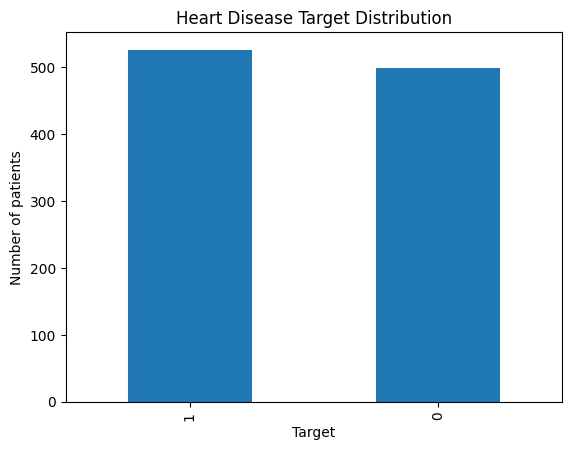

In [ ]:
df["target"].value_counts().plot(kind="bar")
plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of patients")
plt.show()

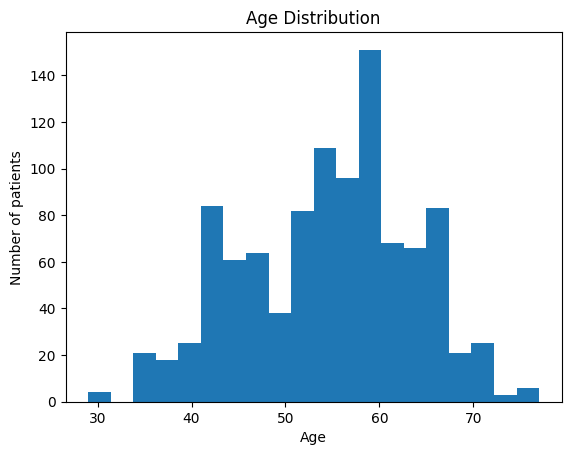

In [ ]:
# Age Distribution
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.show()

In [ ]:
X = features
y = df["target"]

In [ ]:
from numpy.random.mtrand import random
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (820, 13)
X_test: (205, 13)
y_train: (820,)
y_test: (205,)


In [ ]:
# Train the model
model = RandomForestClassifier(n_estimators=100 ,random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Prediction
y_pred = model.predict(X_test)
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1])

In [ ]:
# Percentage of predicted values
percentage_predicted_values = pd.Series(y_pred).value_counts(normalize=True) * 100
percentage_predicted_values

,proportion
1,51.219512
0,48.780488


In [ ]:
# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")

Accuracy: 1.0
Balanced Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(f" Confusion Matric \n {cm}")

 Confusion Matric 
 [[100   0]
 [  0 105]]


In [ ]:
classi_report = classification_report(y_test, y_pred)
print(f" Classification Report \n {classi_report}")

 Classification Report 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [ ]:
# Roc-Auc Score
y_prob = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-Auc: {roc_auc}")

ROC-Auc: 1.0


In [ ]:
train_pred = model.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(y_train, train_pred)
)

print(
    "Testing Accuracy:",
    accuracy_score(y_test, y_pred)
)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [ ]:
# Feature Importance
features_importance = pd.DataFrame({
    "Features": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
features_importance

,Features,Importance
2,chest_pain_type,0.142094
7,max_heart_rate,0.117349
11,cardiac_risk,0.114844
9,oldpeak,0.112634
12,thallium_stress_test,0.095930
0,age,0.091285
4,cholesterol,0.077771
8,exercise_angina,0.073707
3,resting_bp,0.067765
10,st_slope,0.048711


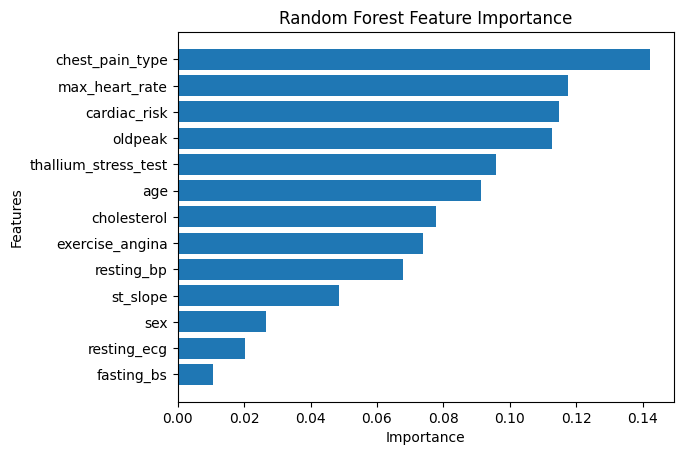

In [ ]:
plt.barh(
    features_importance["Features"],
    features_importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Save the model
import joblib
joblib.dump(model, "/content/drive/MyDrive/Colab Notebooks/Machine Learning/Deployed Models/heartguard_ai.joblib")

['/content/drive/MyDrive/Colab Notebooks/Machine Learning/Deployed Models/heartguard_ai.joblib']

In [ ]:
# Load the model
loaded_model = joblib.load("/content/drive/MyDrive/Colab Notebooks/Machine Learning/Deployed Models/heartguard_ai.joblib")

In [ ]:
# Prediction with loaded model
make_predctions = loaded_model.predict(X_test)
make_predctions

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1])

In [ ]:
# Test the loaded model with sample data of patient

sample_patient = pd.DataFrame([{
      'age': 55,
    'sex': 1,
    'chest_pain_type': 1,
    'resting_bp': 130,
    'cholesterol': 200,
    'fasting_bs': 0,
    'resting_ecg': 1,
    'max_heart_rate': 120,
    'exercise_angina': 0,
    'oldpeak': 1.0,
    'st_slope': 2,
    'cardiac_risk': 1,
    'thallium_stress_test': 2
}])

prediction = loaded_model.predict(sample_patient)[0]

probability = loaded_model.predict_proba(
    sample_patient
)[0][1]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 1
Probability: 0.68


In [ ]:
if prediction == 1:
    print("Potential heart disease risk detected.")
else:
    print("Lower predicted risk according to the model.")

Potential heart disease risk detected.
